An Attempt to run a clifford simulation, probably naively and very stupidly

I don't think this is done, issues with the gate structure not being seeded maybe?

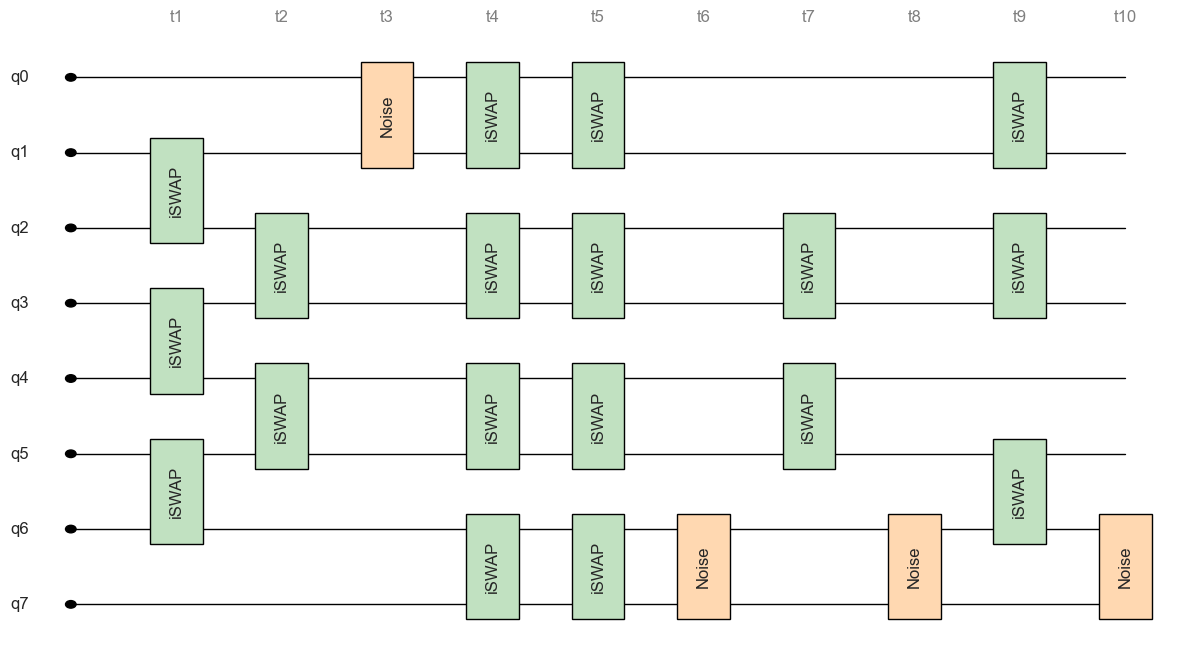

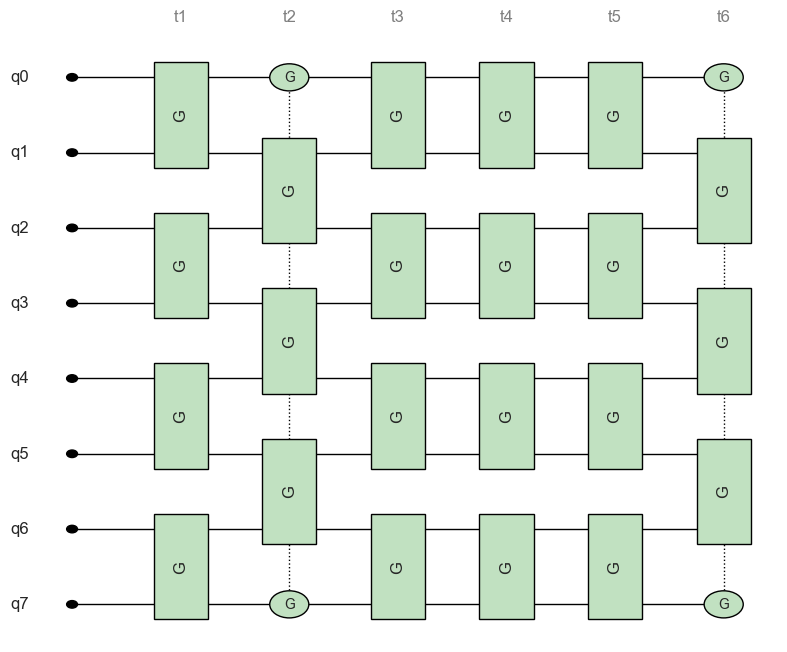

DM 4573195760
16


/Users/elliottrose/Documents/GitHub/QuNet/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


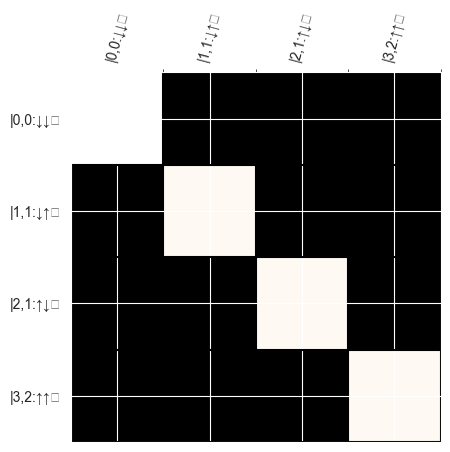

In [1]:
# Add directory above current directory to path
import sys as SYS; SYS.path.insert(0, '..'); SYS.path.insert(0, '../..')
import csv
import numpy as np
import pandas as pd

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import networkx as nx
from scipy import stats
from scipy.stats import gaussian_kde, kurtosis, skew

from src import density_matrix as DM
from src import circuit_architecture
from src import ket
from src import measurements as measure
from Scripts import simulation_CLITEST as cleo
from Scripts import hdf5merge


Run Sim

In [2]:
import os
os.getcwd()

'/Users/elliottrose/Documents/GitHub/QuNet/QuNet_bootcamp_2025'

In [3]:
Trials = 50
num_steps = 500
n_qubits = 8

for unitary_seed in range(Trials):
    #initial_pops = [0.043407, 0.12, 0.09, 0.15, 0.3,0.14, 0.23, 0.026593]
    #initial_pops = [0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]
    initial_pops = [0,0,0,0,1,0,0,0]
    NM_orders_list = {}
    system = DM.n_thermal_qbits(initial_pops)
    connectivity = "c2_2local"
    unitary_energy_subspace = 1
    ordering_seed = 1
    chunk_size = 2
    order_rule_name = "random"
    num_steps = num_steps
    name_for_saving = f"{unitary_seed}"
    data = cleo.execute(file_name=f"random_clifford",
                       connectivity=connectivity,
                       order_rule_name = order_rule_name,
                       unitary_seed=unitary_seed,
                       unitary_energy_subspace=unitary_energy_subspace,
                       evolution_generator_type="u1cliffordunitary",
                       chunk_size=chunk_size,
                       num_steps=num_steps,
                       initial_pops=initial_pops,
                        channel_name="None",
                        NM_orders_list=NM_orders_list,
                        channel_prob=0.0,
                       verbosity = .9);

simulation complete, extracting and saving data to : ../data/random_clifford/random_clifford-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_random
simulation complete, extracting and saving data to : ../data/random_clifford/random_clifford-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_random
simulation complete, extracting and saving data to : ../data/random_clifford/random_clifford-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_random
simulation complete, extracting and saving data to : ../data/random_clifford/random_clifford-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_random
simulation complete, extracting and saving data to : ../data/random_clifford/random_clifford-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_random
simulation complete, extracting and saving data to : ..

In [4]:
hdf5merge.merge_hdf5_files("/Users/elliottrose/Documents/GitHub/QuNet/data/random_clifford")
newdata_random_clifford = dict(h5py.File("/Users/elliottrose/Documents/GitHub/QuNet/data/random_clifford/random_clifford.hdf5"))

Get_Pops

In [5]:
def get_pops(data, n_qubits, connectivity,update_rule):
    #dimension 0 is each trial
    #dimension 1 is each time step
    #dimension 2 is each qubit
    result = []
    for trial in data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1']:
        seed = trial.split(' ')[-1]
        dat = dict(data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1'][f'unitary seed {seed}'][f'ordering seed {update_rule}']['pops'])
        dat = {int(k.split('(')[0]): dat[k] for k in dat}
        dat = np.array([np.array([dat[k][subkey][()] for subkey in sorted(dat[k])]) for k in sorted(dat)])
        result.append(dat)
    return(np.array(result))

In [6]:
pops_random_clifford = get_pops(newdata_random_clifford, n_qubits, "c2_2local", "random")

Node evolution

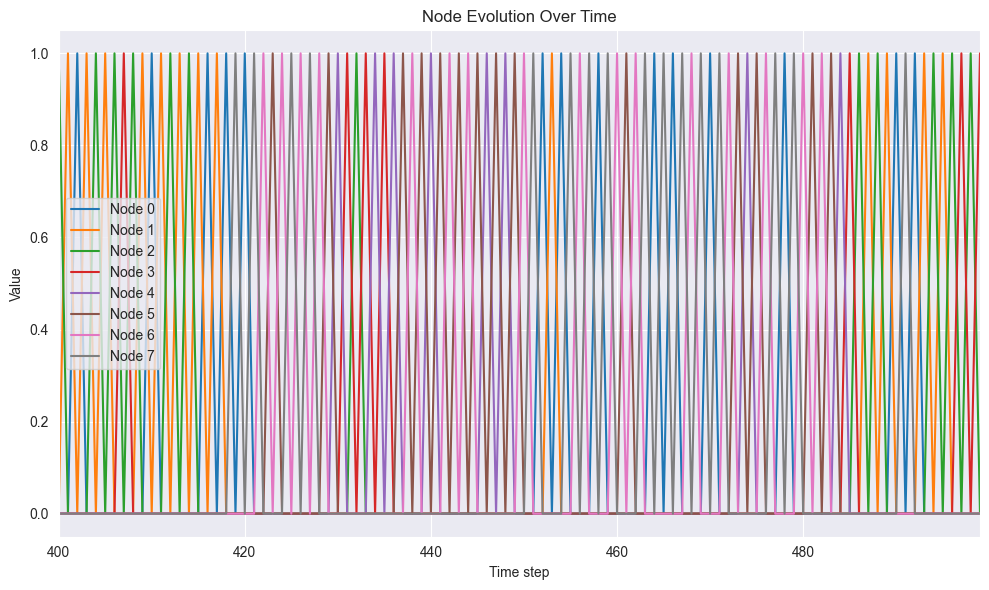

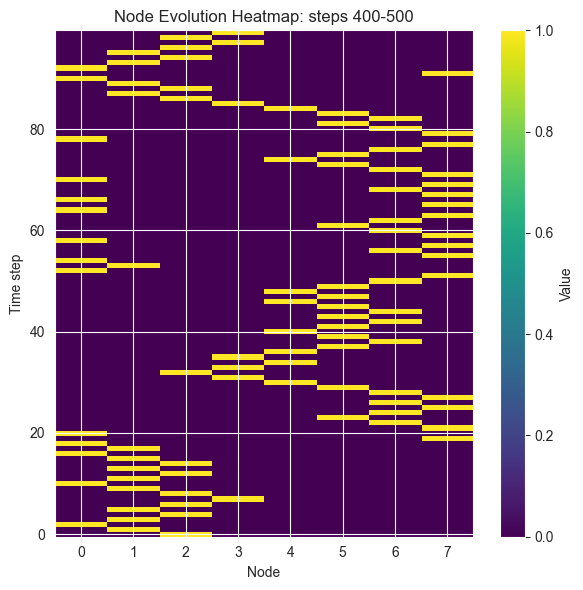

In [7]:
def plot_node_evolution(data, steps_range = None):
    '''
    TODO: docstring
    '''
    data = np.asarray(data)

    # if steps_range are not given, assume we're plotting entire evolution
    if not steps_range:
        time_steps, num_nodes = data.shape
        steps_range = (0, time_steps)
    else:
        data = data[steps_range[0]:steps_range[1]]
        time_steps, num_nodes = data.shape

    # Line plot: evolution of each node
    plt.figure(figsize=(10, 6))
    for i in range(num_nodes):
        plt.plot(range(steps_range[0],steps_range[1]), data[:, i], label=f'Node {i}')
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.xlim(steps_range[0],steps_range[1]-1)
    plt.title('Node Evolution Over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Heatmap: time vs node
    plt.figure(figsize=(6, 6))
    plt.imshow(data, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label='Value')
    plt.xlabel('Node')
    plt.ylabel('Time step')
    plt.title(f'Node Evolution Heatmap: steps {steps_range[0]}-{steps_range[1]}')
    plt.tight_layout()
    plt.show()

#Problem: No seed for my clifford gate generation???
plot_node_evolution(pops_random_clifford[29], steps_range=(400,500))

Tau-Z Statistics

In [8]:
steps = num_steps
denom = 15.0

def tz_two_q_dyns_map(pops_trial_index,denom = 15.0):
    tz = []
    np.array(pops_trial_index)
    for step_index in range(steps):
        tzi =  np.sin(np.pi/denom)*np.sin(np.pi/denom) -2*(pops_trial_index[step_index + 1 ] - np.cos(np.pi / denom)*np.cos(np.pi / denom)* pops_trial_index[step_index])
        tz.append(tzi)
    return tz

In [9]:
def abs_tz(pops,denom):
    abs_tz=[]
    for step in tz_two_q_dyns_map(pops,denom):
        abs_step = [abs(ele) for ele in step]
        abs_tz.append(abs_step)
    return abs_tz

def CPcond(abs_tz_pops) :
    cp_cond=[]
    for step in abs_tz_pops:
        cp_step = [ele + np.cos(np.pi / denom) * np. cos(np.pi / denom)  for ele in step]
        cp_cond.append(cp_step)
    return cp_cond

def means_stds_of_tz_of_one_sim_index(tz_trial_index):
    mean_stds_list = []
    for step_index in range(steps):
        stds = np.std(tz_trial_index [step_index])
        means = np.mean(tz_trial_index[step_index])
        mean_stds_list.append([means, stds])
    return mean_stds_list

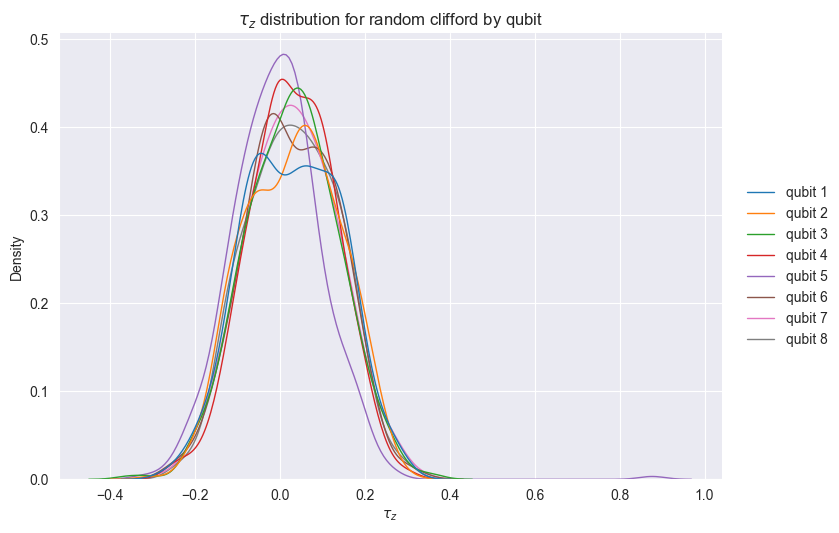

In [10]:
def tau_z_avg_over_trials(pops, denom = 15.0):
    '''
    Calculates tau_z, then takes average over each trial for tau_z values.

    Paramters
    ---------
    pops : array
        Array of populations, with dimensions for (trials, timesteps, qubits)
    denom : float
        Denominator value for pi/denom in trig functions within unitary.

    Returns
    -------
    DataFrame of tau_z values, averaged over trials, cols for qubits, rows for
    timesteps.
    '''
    tz_avg = np.zeros((pops.shape[1]-1, pops.shape[2]))

    # sum tau_z stats for each trial
    for trial_pops in pops:
        tau_z_pops = np.array(tz_two_q_dyns_map(trial_pops, denom = denom))
        tz_avg = np.add(tz_avg, tau_z_pops)

    # divide by number of trials to obtain average values
    tz_avg = tz_avg / float(pops.shape[0])

    # cast results into DataFrame
    col_names = [f'qubit {i+1}' for i in range(n_qubits)]
    return pd.DataFrame(tz_avg, columns=col_names)

tz_trial_avg_df_randclifford = tau_z_avg_over_trials(pops_random_clifford)

def plot_tau_z_dist(df,title=''):
    ax = sns.displot(data=df,kind='kde',linewidth=1.0,
                    height=5, aspect=1.5)
    ax.set(xlabel=r'$\tau_z$',
        title=title)

plot_tau_z_dist(tz_trial_avg_df_randclifford,title=r'$\tau_z$ distribution for random clifford by qubit')

In [11]:
pops_random_clifford.shape

(50, 501, 8)

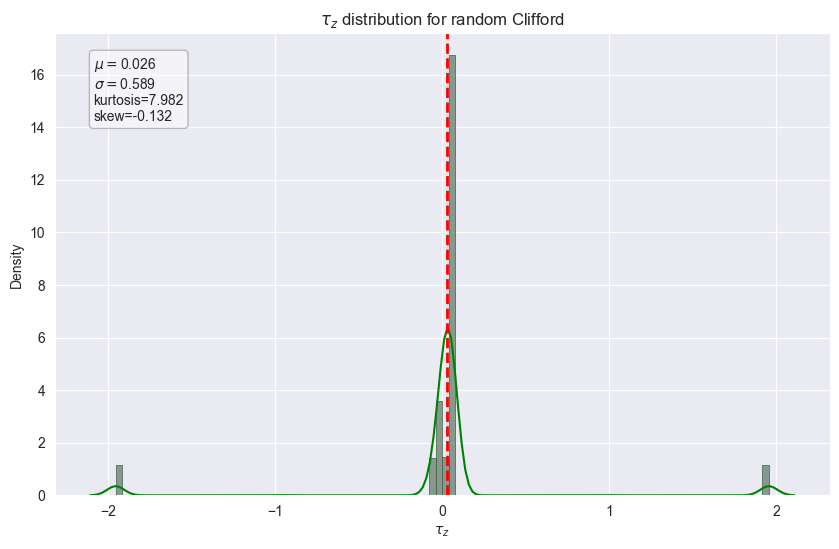

In [12]:
def tau_z_tot_avg_plot(pops, title=''):
    tz_arr = np.array([])
    for trial_pops in pops:
        tau_z_pops = np.array(tz_two_q_dyns_map(trial_pops, denom = denom))
        tz_arr = np.append(tz_arr, tau_z_pops)

    fig, my_ax = plt.subplots(figsize=(10,6))

    # ax = sns.histplot(data=tz_arr, kde=False, stat='density',bins=50, color='grey')
    sns.histplot(data=tz_arr, kde=False, stat='density',bins=100, color='#63806a', edgecolor='#445c4a', ax=my_ax)
    sns.kdeplot(data=tz_arr, color='g', alpha=1, lw=1.5, ax=my_ax)

    my_ax.axvline(np.mean(tz_arr),linestyle='dashed',lw=2,c='r')

    # place text box
    textstr = '\n'.join((
        rf'$\mu=${np.mean(tz_arr):.3f}',
        rf'$\sigma=${np.std(tz_arr):.3f}',
        rf'kurtosis={kurtosis(tz_arr):.3f}',
        rf'skew={skew(tz_arr):.3f}'
        ))

    # these are matplotlib.patch.Patch properties
    props = dict(boxstyle='round', facecolor='white', edgecolor='grey',alpha=0.5)

    # place a text box in upper left in axes coords
    my_ax.text(0.05, 0.95, textstr, transform=my_ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)


    my_ax.set(xlabel=r'$\tau_z$',
        title=title)

    return tz_arr

res = tau_z_tot_avg_plot(pops_random_clifford, title=r'$\tau_z$ distribution for random Clifford')

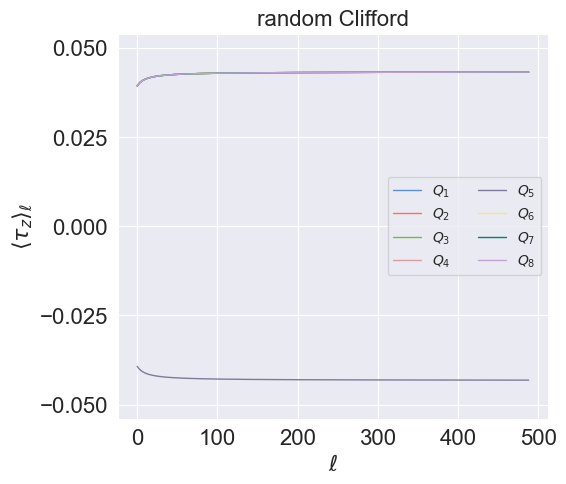

In [13]:
def time_averaged_one_point_measures_at_t(dataset,t):
    '''
    Takes in dataset for one trial. Takes ensemble average along the first axis
    (averaging over all datasets).

    Parameters
    ----------
    - dataset : list of n lists, for n time steps, in total corresponding to
        one trial.
    - t : int, cutoff time step.

    Returns
    -------
    - dataset averaged over time axis
    '''

    sum_till_t = np.sum(dataset[:t], axis=0)
    time_average_t = (1/(t+1))*(sum_till_t)

    return (time_average_t)

def time_averaged_one_point_measures_matrix_full_sim(dataset):
    # Take the ensemble average along the first axis (averaging over all datasets)
    '''
    Take the ensemble average along the first axis (averaging over all datasets).
    '''
    time_average=[]
    for t in range(len(dataset)):
        time_average.append(time_averaged_one_point_measures_at_t(dataset,t))

    return (time_average)

def plot_connectivity(
    pops_list,
    seed=50,
    denom=15,
    ytherm12=(0.1*11+0.4)/12,  # Default value, adjust as needed
    colors=None,
    dataset_label=None,
    population_titles = ["$R_{1}$", "$R_{2}$", "$R_{3}$", "$R_{4}$", "$R_{5}$"]
):
    """
    Create a 2x5 grid of plots comparing C2 and C4 connectivity for different populations.

    Parameters
    ----------
    pops_list : list[array]
        Each array is populations from get_pops().
    seed : int
        Seed to use for time-averaged plots
    denom : int
        Denominator value for calculations
    ytherm10 : float
        Thermal value for reference line
    colors : list
        List of colors to use for plotting
    dataset_label : str
        Label to use in saved filenames. If None is given, plot will not save.
    """
    if colors is None:
        colors = ['#5B8FD8', '#FF6F61', '#6DBE45', '#D79F9D', '#7E7B9A','#F0E68C', '#008080', '#C2A2D2', '#D04E00', '#A8E6CF','#FFDAB9', '#B2B09C']

    # Create figure with GridSpec for better control
    fig = plt.figure(figsize=(30, 12))
    gs = GridSpec(2, 5, figure=fig, wspace=0.1, hspace=0.4)

    # Row 1: Time-Averaged Plots for different populations (seed=50)
    row1_title = "Time-Averaged Plots (seed=50)"

    # Function to create time-averaged plot
    def create_time_averaged_plot(ax, pops, pop_idx, conn, title, y_global_min, y_global_max):
        data = time_averaged_one_point_measures_matrix_full_sim(tz_two_q_dyns_map(pops[pop_idx][seed], denom))
        data = np.array(data[10:499])
        num_time_steps = len(data)
        t = np.arange(num_time_steps)
        data_transposed = data.T

        # Use the global min and max values for consistent y-axis scaling
        ax.set_ylim(y_global_min, y_global_max)

        # Set consistent number of y-axis ticks (e.g., 5 ticks)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        # TODO: figure out what ytherm does
        # ax.axhline(y=(1-2*ytherm12)*(np.sin((np.pi)/denom))**2, color='r', linestyle='--',
        #           label=r'$\tau_z^*$'f' = {0.03242}')

        for i, y_values in enumerate(data_transposed):
            color = colors[i % len(colors)]
            ax.plot(t, y_values, label=f'$Q_{{{i+1}}}$', color=color, linewidth=1)

        if pop_idx == 0:
            ax.tick_params(axis='both', which='major', labelsize=14)
        else:
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax.tick_params(axis='both',labelsize=16)

        ax.set_xlabel(r'$\ell$', fontsize=16)
        if pop_idx==0:
            ax.set_ylabel(r'$\langle \tau_{z} \rangle _\ell$', fontsize=16)
        ax.set_title(f'{title}', fontsize=16)

        # Only add legend to the first plot in each row to save space
        if pop_idx == 2:
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                     ncol=13, fontsize=16)

    # Main plotting code
    # First, determine global min/max across all datasets
    y_global_min = float('inf')
    y_global_max = float('-inf')

    for pop_idx in range(len(pops_list)):
        data = time_averaged_one_point_measures_matrix_full_sim(tz_two_q_dyns_map(pops_list[pop_idx][seed], denom))
        data = np.array(data[10:499])
        curr_min = np.min(data)
        curr_max = np.max(data)

        # Add some padding as in your original code
        curr_min = curr_min - 0.25 * abs(curr_min)
        curr_max = curr_max + 0.25 * abs(curr_max)

        y_global_min = min(y_global_min, curr_min)
        y_global_max = max(y_global_max, curr_max)

    # Now create all plots with the same y-axis limits
    for pop_idx in range(len(pops_list)):
        ax1 = fig.add_subplot(gs[0, pop_idx])
        create_time_averaged_plot(ax1, pops_list, pop_idx, "C2", population_titles[pop_idx],
                                y_global_min, y_global_max)

    plt.legend(fontsize=10,ncol=2)
    plt.grid(True)

    if dataset_label:
        plt.savefig(f'tz_time_Averaged_comparison_c2_12)q_{dataset_label}.pdf', format='pdf', bbox_inches='tight')

    plt.show()

# TODO: prepare pops_list
pops_list = [pops_random_clifford]

y_min=np.min(pops_list)
y_max = np.max(pops_list)

# Call the function with seed=50
plot_connectivity(
    pops_list,
    seed=35,
    #ytherm12=ytherm12,  # Adjust this value as needed
    population_titles = ["random Clifford"]
)

<Axes: xlabel='$\\tau_Z$', ylabel='Density'>

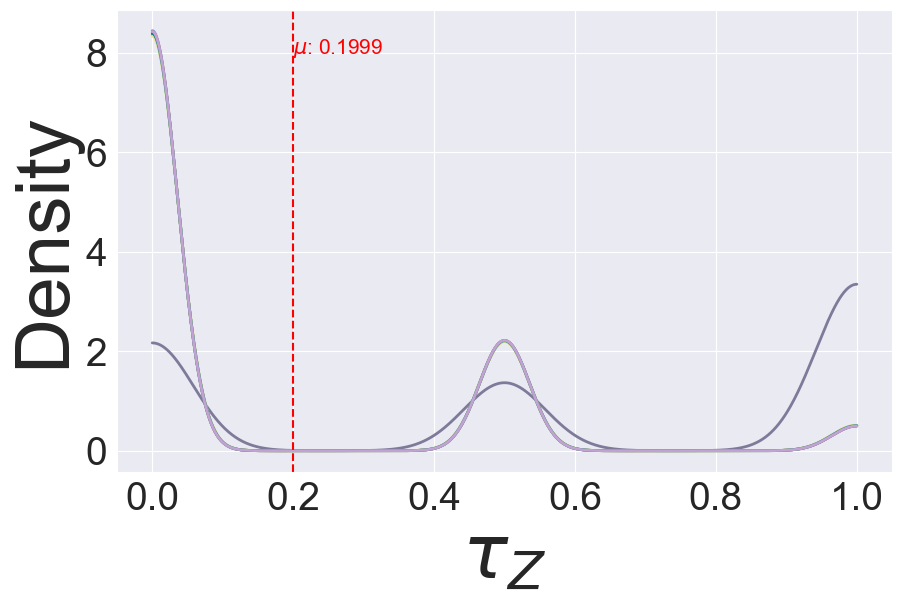

In [14]:
#TODO: what does this plot actually plot????
def plot_aggregate_density(data, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Set up colors
    colors =['#5B8FD8', '#FF6F61', '#6DBE45', '#D79F9D', '#7E7B9A','#F0E68C', '#008080', '#C2A2D2', '#D04E00', '#A8E6CF','#FFDAB9', '#B2B09C']

    # For each position
    for pos in range(data.shape[2]):
        # Collect all values for this position across all datasets and trials
        all_position_values = data[:, :, pos].flatten()

        # Calculate the KDE
        x = np.linspace(np.min(all_position_values), np.max(all_position_values), 1000)
        kde = gaussian_kde(all_position_values)

        # Plot the density on the provided axis
        ax.plot(x, kde(x), color=colors[pos], linewidth=2)

        # Optional: Add a small rug plot to show actual data distribution
        #ax.plot(all_position_values, np.zeros_like(all_position_values) - 0.005 * (pos+1),
        #        '|', color=colors[pos], alpha=1, markersize=5)

        ax.tick_params(axis='both',labelsize=28)

    # Add visual enhancements
    #ax.set_title('Aggregate Probability Density of Values Across All Datasets and Trials', fontsize=16)
    ax.set_xlabel(r'$\tau_Z$', fontsize=54)
    ax.set_ylabel('Density', fontsize=55)

    # Add mean line
    if data.sum() / (data.size) != 0:
        mean_value = data.mean()
        ax.axvline(x=mean_value, color='red', linestyle='--')
        ax.text(mean_value, ax.get_ylim()[1]*0.9, r'$\mu$'f': {mean_value:.4f}',
                color='red', fontsize=15)

    return ax

plot_aggregate_density(pops_random_clifford)

Connectivity

In [15]:
def get_2_qbit_dms(data, n_qubits, connectivity,update_rule):
    basis = ket.canonical_basis(2)
    #dimension 0 is each trial
    #dimension 1 is each time step (recall that sampling step is 5 by default)
    #dimension 2 is qubit pair
    #dimension 3 and 4 is the 2 qubit density matrix
    result = []

    def to_tuple(string):
        tuple_elements = string.strip('()').split(',')
        return tuple(int(elem.strip()) for elem in tuple_elements)

    for trial in data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1']:
        seed = trial.split(' ')[-1]
        dat = dict(data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1'][f'unitary seed {seed}'][f'ordering seed {update_rule}']['two_qubit_dms'])
        dat = {int(k.split('(')[0]): dat[k] for k in dat}

        dat = np.array([{to_tuple(subkey):DM.DensityMatrix(dat[k][subkey],basis) for subkey in sorted(dat[k])} for k in sorted(dat)])
        result.append(dat)
    return(np.array(result))

def extract_observables(two_qubit_dms, n_qubits):
    """
    Extract single-qubit σz expectation values and two-qubit correlations from density matrices.

    Args:
        two_qubit_dms: Array of shape (n_trials, n_timesteps, n_pairs) containing dictionaries
                       with two-qubit density matrices
        n_qubits: Number of qubits in the system

    Returns:
        sz: Array of shape (n_trials, n_timesteps, n_qubits) with σz expectation values
        corr: Array of shape (n_trials, n_timesteps, n_qubits, n_qubits) with σz-σz correlations
    """
    n_trials = two_qubit_dms.shape[0]
    n_timesteps = two_qubit_dms.shape[1]

    # Pauli Z matrix
    pauli_z = np.array([[1, 0], [0, -1]], dtype=complex)
    pauli_z_tensor = np.kron(pauli_z, pauli_z)

    # Initialize arrays as complex to avoid casting warnings
    sz = np.zeros((n_trials, n_timesteps, n_qubits), dtype=complex)
    corr = np.zeros((n_trials, n_timesteps, n_qubits, n_qubits), dtype=complex)

    # For each trial and timestep
    for trial in range(n_trials):
        for t in range(n_timesteps):
            # Count how many times each qubit appears to average properly
            counts = np.zeros(n_qubits)

            # For each qubit pair
            for pair, dm in two_qubit_dms[trial, t].items():
                i, j = pair

                # Get density matrix as numpy array
                rho = dm.data

                # Calculate local observables
                sz_i = np.trace(rho @ np.kron(pauli_z, np.eye(2, dtype=complex)))
                sz_j = np.trace(rho @ np.kron(np.eye(2, dtype=complex), pauli_z))

                # Calculate correlation
                corr_ij = np.trace(rho @ pauli_z_tensor) - sz_i * sz_j

                # Update counts
                counts[i] += 1
                counts[j] += 1

                # Update expectation values (will average later)
                sz[trial, t, i] += sz_i
                sz[trial, t, j] += sz_j

                # Store correlation
                corr[trial, t, i, j] = corr_ij
                corr[trial, t, j, i] = corr_ij

            # Average the expectation values
            for i in range(n_qubits):
                if counts[i] > 0:
                    sz[trial, t, i] /= counts[i]

    # Take real parts at the end - for Hermitian observables like Pauli-Z
    # the expectation values should be real, with any imaginary component
    # coming from numerical imprecision
    return sz.real, corr.real

    return sz, corr

In [16]:
twoQdms_random_clifford = get_2_qbit_dms(newdata_random_clifford,n_qubits,"c2_2local", "random")

In [17]:
corr_random_clifford = extract_observables(twoQdms_random_clifford, n_qubits)

/var/folders/bn/rlrcnzv54rz0phyhcbjh1x4r0000gn/T/ipykernel_48199/1741927344.py:305: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 3
  axes[i, j].legend(handles=handles, labels=labels_list,


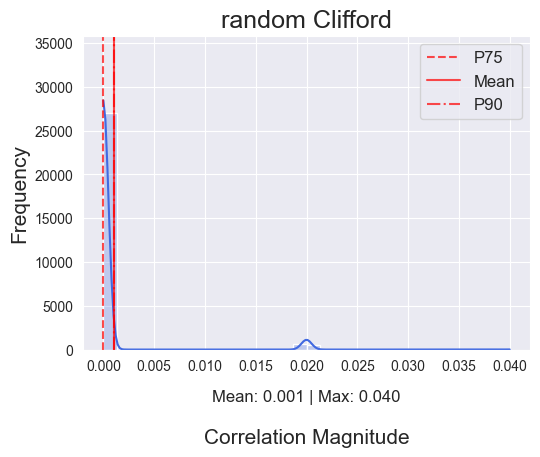

In [18]:
def plot_multiple_correlation_distributions(correlation_datasets, labels, colors, bins=30):
    """
    Plot correlation magnitude distributions for multiple datasets in a single row
    with square-like aspect ratio for each plot.

    Args:
        correlation_datasets: List of correlation arrays or tuples
        labels: List of labels for each dataset
        colors: List of colors for each dataset
        bins: Number of histogram bins (default: 30)

    Returns:
        fig: The figure object
        stats_dict: Dictionary with correlation statistics for each dataset
    """
    # Calculate figure size based on number of datasets to maintain square plots
    n_datasets = len(correlation_datasets)
    # Height of 4, width scales with number of datasets (3.5 per dataset)
    figsize = (6, 7)

    # Create figure
    fig, axes = plt.subplots(1, n_datasets, figsize=figsize)

    # Handle case of single dataset
    if n_datasets == 1:
        axes = [axes]

    # Container for statistics
    stats_dict = {}

    # Process each dataset
    for i, corr_data in enumerate(correlation_datasets):
        # Handle case where input might be a tuple
        if isinstance(corr_data, tuple) and len(corr_data) >= 2:
            corr = corr_data[1]  # Extract correlations
        else:
            corr = corr_data

        # Get dimensions
        if len(corr.shape) == 4:
            n_trials, n_timesteps, n_qubits, _ = corr.shape
        else:
            # Handle case where there might not be multiple trials
            n_timesteps, n_qubits, _ = corr.shape
            n_trials = 1
            corr = corr.reshape(1, n_timesteps, n_qubits, n_qubits)

        # Calculate correlation magnitudes (absolute values)
        corr_abs = np.abs(corr)

        # Average over trials
        avg_corr_abs = np.mean(corr_abs, axis=0)

        # Create mask to exclude self-correlations (diagonal elements)
        mask = ~np.eye(n_qubits, dtype=bool)
        mask_3d = np.broadcast_to(mask, (n_timesteps, n_qubits, n_qubits))

        # Extract off-diagonal elements for each time step
        off_diag_values = []
        for t in range(n_timesteps):
            off_diag_values.append(avg_corr_abs[t][mask])

        # Calculate statistics
        means = np.array([np.mean(vals) for vals in off_diag_values])
        medians = np.array([np.median(vals) for vals in off_diag_values])
        max_vals = np.array([np.max(vals) for vals in off_diag_values])
        percentile_75 = np.array([np.percentile(vals, 75) for vals in off_diag_values])
        percentile_90 = np.array([np.percentile(vals, 90) for vals in off_diag_values])

        # Calculate overall statistics
        overall_stats = {
            'mean': np.mean(means),
            'median': np.median(medians),
            'max': np.max(max_vals),
            'p75': np.mean(percentile_75),
            'p90': np.mean(percentile_90)
        }

        # Create recommended thresholds
        recommended_thresholds = [
            overall_stats['p75'],  # Conservative
            overall_stats['mean'],        # Moderate
            overall_stats['p90']         # Stringent
        ]

        # Round thresholds for clarity
        recommended_thresholds = [round(t, 3) for t in recommended_thresholds]

        # Store statistics for this dataset
        stats_dict[labels[i]] = {
            'overall': overall_stats,
            'by_time': {
                'mean': means,
                'median': medians,
                'max': max_vals,
                'p75': percentile_75,
                'p90': percentile_90
            },
            'recommended_thresholds': recommended_thresholds
        }

        # Flatten all off-diagonal correlations from all time steps for plotting
        all_corrs = np.concatenate(off_diag_values)

        # Plot histogram with KDE
        sns.histplot(all_corrs, bins=bins, kde=True, color=colors[i], alpha=0.25, ax=axes[i])

        # Add vertical lines for recommended thresholds
        for j, threshold in enumerate(recommended_thresholds):
            linestyle = ['--', '-', '-.'][j % 3]
            axes[i].axvline(x=threshold, color='r', linestyle=linestyle,
                          alpha=0.7, label=f'Threshold: {threshold:.3f}')

        # Set labels and title
        axes[i].set_xlabel('Correlation Magnitude')
        if i == 0:  # Only add y-label to the first plot
            axes[i].set_ylabel('Frequency')
        else:
            axes[i].set_ylabel('')  # Remove y-labels from other plots

        axes[i].set_title(f'{labels[i]}')

        # Make the plot more square by adjusting y-limits
        # Get current y-limit
        y_max = axes[i].get_ylim()[1]
        # Set a reasonable y-limit to make plots more square
        axes[i].set_ylim(0, y_max * 1.2)

        # Add stats below the plot
        stats_text = (f"Mean: {overall_stats['mean']:.3f} | "
                     f"Median: {overall_stats['median']:.3f} | "
                     f"Max: {overall_stats['max']:.3f}")

        thresholds_text = (f"Thresholds: {recommended_thresholds[0]:.3f}, "
                          f"{recommended_thresholds[1]:.3f}, "
                          f"{recommended_thresholds[2]:.3f}")

        axes[i].annotate(stats_text, xy=(0.5, -0.15), xycoords='axes fraction',
                       ha='center', va='center', fontsize=9)

        axes[i].annotate(thresholds_text, xy=(0.5, -0.25), xycoords='axes fraction',
                       ha='center', va='center', fontsize=9)

    #plt.tight_layout(rect=[0, 0.15, 1, 0.95])  # Add space at the bottom for annotations

    return fig, stats_dict


# Create a new function to plot all ICs at once in a grid
def plot_all_correlations_grid(ic_all_datas, corrs_all_datas, colors=None, label = ''):
    """
    Plot all correlation datasets in a grid, with each row corresponding to an IC type
    and each column to a different rule.

    Args:
        ic_all_datas: List of IC types
        corrs_all_datas: 2D list of correlation datasets (rows=IC types, cols=rules)
        colors: List of colors for each rule

    Returns:
        fig: The figure object
    """
    n_ics = len(ic_all_datas)
    n_rules = len(corrs_all_datas[0]) if corrs_all_datas and corrs_all_datas[0] else 1

    if colors is None:
        colors = ['#4169E1']
    markers = ['o']  # circle, diamond, triangle, square

    # Create a larger figure for the grid
    fig, axes = plt.subplots(n_ics, n_rules, figsize=(n_rules * 5.5, n_ics * 5.5))

    # Handle the case where we have only one subplot
    if n_ics == 1 and n_rules == 1:
        axes = np.array([[axes]])  # Make it 2D
    elif n_ics == 1:
        axes = axes.reshape(1, -1)  # Make it 2D with one row
    elif n_rules == 1:
        axes = axes.reshape(-1, 1)  # Make it 2D with one column

    #Max y per row
    max_ylims = [0] * n_ics

    # Define rule names
    rule_names = ['NonMarkovian'] #TODO: if needed again: [f'R{i+1}' for i in range(n_rules)]

    # Container for statistics
    all_stats = {}

    # Process each IC type and rule
    for i, (IC, corr_row) in enumerate(zip(ic_all_datas, corrs_all_datas)):
        for j, corr_data in enumerate(corr_row):
            # Process this specific correlation dataset

            # Handle case where input might be a tuple
            if isinstance(corr_data, tuple) and len(corr_data) >= 2:
                corr = corr_data[1]  # Extract correlations
            else:
                corr = corr_data

            # Get dimensions
            if len(corr.shape) == 4:
                n_trials, n_timesteps, n_qubits, _ = corr.shape
            else:
                # Handle case where there might not be multiple trials
                n_timesteps, n_qubits, _ = corr.shape
                n_trials = 1
                corr = corr.reshape(1, n_timesteps, n_qubits, n_qubits)

            # Calculate correlation magnitudes (absolute values)
            corr_abs = np.abs(corr)

            # Average over trials
            avg_corr_abs = np.mean(corr_abs, axis=0)

            # Create mask to exclude self-correlations (diagonal elements)
            mask = ~np.eye(n_qubits, dtype=bool)
            mask_3d = np.broadcast_to(mask, (n_timesteps, n_qubits, n_qubits))

            # Extract off-diagonal elements for each time step
            off_diag_values = []
            for t in range(n_timesteps):
                off_diag_values.append(avg_corr_abs[t][mask])

            # Calculate statistics
            means = np.array([np.mean(vals) for vals in off_diag_values])
            medians = np.array([np.median(vals) for vals in off_diag_values])
            max_vals = np.array([np.max(vals) for vals in off_diag_values])
            percentile_75 = np.array([np.percentile(vals, 75) for vals in off_diag_values])
            percentile_90 = np.array([np.percentile(vals, 90) for vals in off_diag_values])

            # Calculate overall statistics
            overall_stats = {
                'mean': np.mean(means),
                'median': np.median(medians),
                'max': np.max(max_vals),
                'p75': np.mean(percentile_75),
                'p90': np.mean(percentile_90)
            }

            # Create recommended thresholds
            recommended_thresholds = [
                overall_stats['p75'] ,
                overall_stats['mean'],        # Moderate
                overall_stats['p90']         # Stringent
            ]

            # Round thresholds for clarity
            recommended_thresholds = [round(t, 3) for t in recommended_thresholds]

            # Store statistics
            key = f"{IC}_{rule_names[j]}"
            all_stats[key] = {
                'overall': overall_stats,
                'recommended_thresholds': recommended_thresholds
            }

            # Flatten all off-diagonal correlations from all time steps for plotting
            all_corrs = np.concatenate(off_diag_values)

            # Plot histogram with KDE
            sns.histplot(all_corrs, bins=30, kde=True, color=colors[j], alpha=0.25, ax=axes[i, j])

            # Add vertical lines for recommended thresholds
            for k, threshold in enumerate(recommended_thresholds):
                linestyle = ['--', '-', '-.'][k % 3]
                threshold_key=["P75","Mean","P90"]
                if (i,j) == (0,0):
                    axes[i, j].axvline(x=threshold, color='r', linestyle=linestyle,
                              alpha=0.7, label=f'{threshold_key[k]}')
                else:
                    axes[i, j].axvline(x=threshold, color='r', linestyle=linestyle,
                              alpha=0.7, label='')

            # Don't call legend() here - we'll combine all elements later

            # Set labels and title
            if i == n_ics - 1:  # Only add x-label to the bottom row
                axes[i, j].set_xlabel('Correlation Magnitude', fontsize=15)
                axes[i, j].xaxis.set_label_coords(0.5, -0.25)
            else:
                axes[i, j].set_xlabel('')

            if j == 0:  # Only add y-label to the first column
                axes[i, j].set_ylabel(f'Frequency', fontsize=15)
            else:
                axes[i, j].set_ylabel('')

            if i == 0:
                axes[i, j].set_title(label, fontsize=18)
            else:
                axes[i, j].set_xlabel('')

            # Create custom handle for scatter plot legend
            custom_handle = mpl.lines.Line2D([0], [0], marker=markers[i], color=colors[j],
                             markersize=8, linestyle='None')

            # Get current handles and labels from threshold lines
            handles, labels_list = axes[i, j].get_legend_handles_labels()

            # Add custom handle to handles list
            handles.append(custom_handle)

            # Now create a single legend with all elements
            axes[i, j].legend(handles=handles, labels=labels_list,
                      loc='upper right', fontsize=12)

            y_max = axes[i, j].get_ylim()[1]
            max_ylims[i] = max(max_ylims[i], y_max)

            # Make the plot more square by adjusting y-limits
            # Get current y-limit
            #y_max = axes[i, j].get_ylim()[1]
            # Set a reasonable y-limit to make plots more square

            # Add stats below the plot
            stats_text = (f"Mean: {overall_stats['mean']:.3f} | "
                         f"Max: {overall_stats['max']:.3f}")

            #thresholds_text = (f"Thresholds: {recommended_thresholds[1]:.3f}")

            # Use smaller font size for the annotations due to the grid layout
            axes[i, j].annotate(stats_text, xy=(0.5, -0.15), xycoords='axes fraction',
                           ha='center', va='center', fontsize=12)

            #axes[i, j].annotate(thresholds_text, xy=(0.5, -0.25), xycoords='axes fraction',
             #             ha='center', va='center', fontsize=8)

    # Adjust layout with room for annotations
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    for i in range(n_ics):
        # Find maximum y-limit in this row
        row_max = max(axes[i, j].get_ylim()[1] for j in range(n_rules))
        # Apply to all plots in the row
        for j in range(n_rules):
            axes[i, j].set_ylim(0, row_max * 1.2)

    return fig, all_stats


ic_all_datas = ['IC_{th}']
corrs_all_datas = [[corr_random_clifford]]

# Define colors for each rule
colors = ['#4169E1', '#DC143C', '#228B22', '#FF8C00', '#8A2BE2']

# Plot all data in a single grid
fig, all_stats = plot_all_correlations_grid(ic_all_datas, corrs_all_datas, colors, label = f'random Clifford')

# Save the figure
# plt.savefig('all_correlation_distributions_grid_12q_c4.png', dpi=300 ,bbox_inches='tight')
plt.show()

Connectivity Graph

In [19]:
def mutual_info_dicts(twoQdms, trial_index):
    mutual_info_list = []
    for time_step in twoQdms[trial_index]:
        mutual_info_dict = {}
        mutual_info = measure.mutual_information_of_every_pair_dict(time_step)
        # Filter out values below the precision threshold
        filtered_mutual_info = {k: v if v >= 1e-6 else 0 for k, v in mutual_info.items()}
        # Update the mutual_info_dict with the filtered mutual info for the current time step
        mutual_info_dict.update(filtered_mutual_info)
        # Append the mutual_info_dict to the list
        mutual_info_list.append(mutual_info_dict)
    return mutual_info_list

# Call the two_point_dict function for each trial index
# Get the list of dictionaries containing two point values for each time step
def create_adjacency_matrix_two_dim(two_point_dict, num_nodes):
    adjacency_matrix = [[0] * num_nodes for _ in range(num_nodes)]
    for (node1, node2), two_point_value in two_point_dict.items():
        adjacency_matrix[node1][node2] = two_point_value
        adjacency_matrix[node2][node1] = two_point_value  # Assuming undirected graph
    return adjacency_matrix

def adjacency_matrices_list_two_dim(twoQdms, trial_index, num_nodes, two_point_dicts):
    # Get the list of dictionaries containing mutual information values for each time step
    two_point_dicts_list = two_point_dicts(twoQdms, trial_index)
    # Create adjacency matrices for each time step
    adjacency_matrices = []
    for two_point_dict in two_point_dicts_list:
        adj_matrix = create_adjacency_matrix_two_dim(two_point_dict, num_nodes)
        adjacency_matrices.append(adj_matrix)
    return adjacency_matrices

def generate_all_adjacency_matrices(twoQdms, num_seeds, num_qubits, mutual_info_dicts):
    # Initialize an empty list to store the adjacency matrices for each trial
    all_trials_adjacency_matrices = []

    # Loop over each seed from 0 to num_seeds-1
    for seed in range(num_seeds):
        # Generate an empty list to store adjacency matrices for this trial
        trial_matrices = []

        # Generate the adjacency matrix for the given seed
        adj_matrix = adjacency_matrices_list_two_dim(twoQdms, seed, num_qubits, mutual_info_dicts)

        # Append each generated adjacency matrix to the trial-specific list
        trial_matrices.append(adj_matrix)

        # Append the list of matrices for this trial to the overall list
        all_trials_adjacency_matrices.append(trial_matrices)

    # Convert to a NumPy array if needed
    all_trials_adjacency_matrices_array = np.array(all_trials_adjacency_matrices)

    return all_trials_adjacency_matrices_array

In [20]:
def mutual_info_dicts(twoQdms, trial_index):
    mutual_info_list = []
    for time_step in twoQdms[trial_index]:
        mutual_info_dict = {}
        mutual_info = measure.mutual_information_of_every_pair_dict(time_step)
        # Filter out values below the precision threshold
        filtered_mutual_info = {k: v if v >= 1e-6 else 0 for k, v in mutual_info.items()}
        # Update the mutual_info_dict with the filtered mutual info for the current time step
        mutual_info_dict.update(filtered_mutual_info)
        # Append the mutual_info_dict to the list
        mutual_info_list.append(mutual_info_dict)
    return mutual_info_list

# Call the two_point_dict function for each trial index
# Get the list of dictionaries containing two point values for each time step
def create_adjacency_matrix_two_dim(two_point_dict, num_nodes):
    adjacency_matrix = [[0] * num_nodes for _ in range(num_nodes)]
    for (node1, node2), two_point_value in two_point_dict.items():
        adjacency_matrix[node1][node2] = two_point_value
        adjacency_matrix[node2][node1] = two_point_value  # Assuming undirected graph
    return adjacency_matrix

def adjacency_matrices_list_two_dim(twoQdms, trial_index, num_nodes, two_point_dicts):
    # Get the list of dictionaries containing mutual information values for each time step
    two_point_dicts_list = two_point_dicts(twoQdms, trial_index)
    # Create adjacency matrices for each time step
    adjacency_matrices = []
    for two_point_dict in two_point_dicts_list:
        adj_matrix = create_adjacency_matrix_two_dim(two_point_dict, num_nodes)
        adjacency_matrices.append(adj_matrix)
    return adjacency_matrices

def generate_all_adjacency_matrices(twoQdms, num_seeds, num_qubits, mutual_info_dicts):
    # Initialize an empty list to store the adjacency matrices for each trial
    all_trials_adjacency_matrices = []

    # Loop over each seed from 0 to num_seeds-1
    for seed in range(num_seeds):
        # Generate an empty list to store adjacency matrices for this trial
        trial_matrices = []

        # Generate the adjacency matrix for the given seed
        adj_matrix = adjacency_matrices_list_two_dim(twoQdms, seed, num_qubits, mutual_info_dicts)

        # Append each generated adjacency matrix to the trial-specific list
        trial_matrices.append(adj_matrix)

        # Append the list of matrices for this trial to the overall list
        all_trials_adjacency_matrices.append(trial_matrices)

    # Convert to a NumPy array if needed
    all_trials_adjacency_matrices_array = np.array(all_trials_adjacency_matrices)

    return all_trials_adjacency_matrices_array